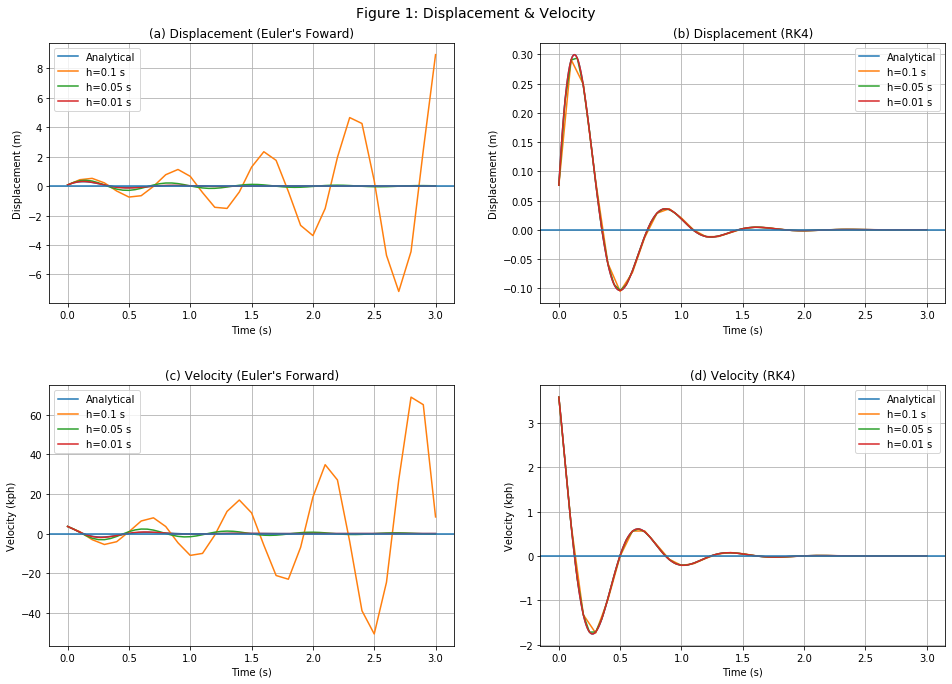

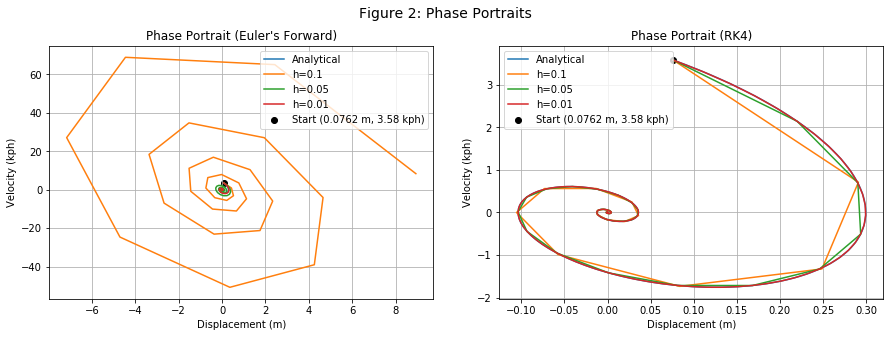

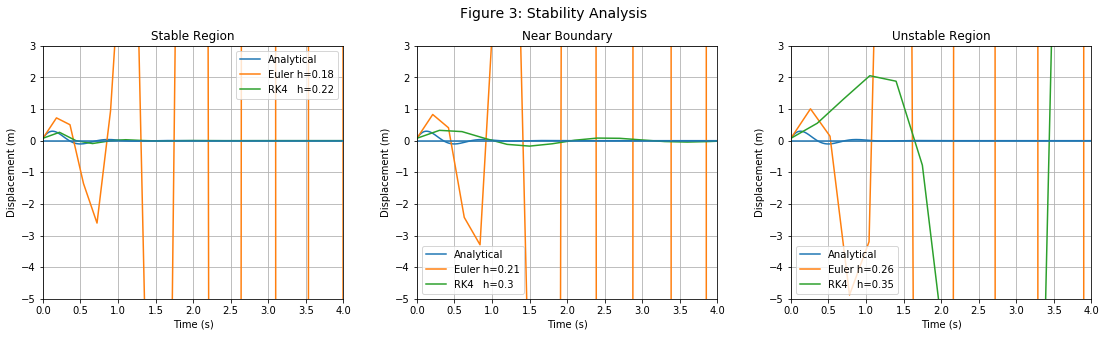

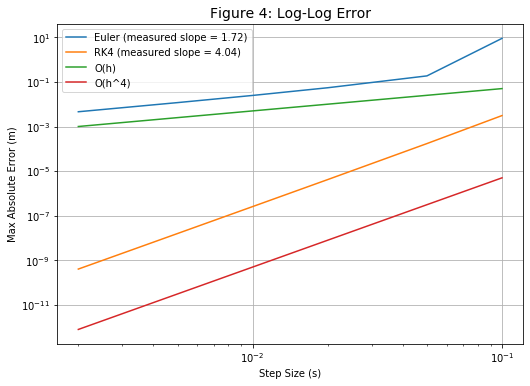

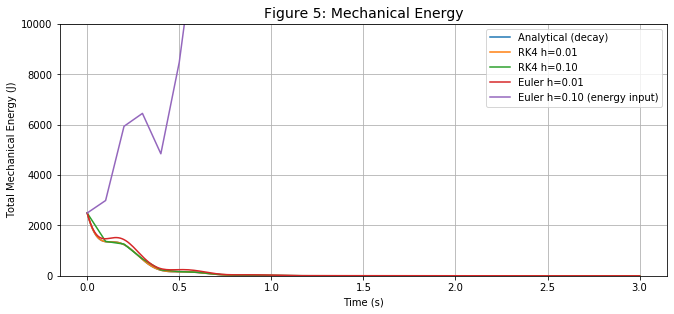

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# parameters
m    = 375.35
k    = 30000.0
zeta = 0.32
y0   = 0.0762
v0   = 3.58
t    = 3.0

# derived parameters
omega_n = np.sqrt(k / m)
omega_d = omega_n * np.sqrt(1 - zeta**2)
c    = 2 * zeta * np.sqrt(m * k)

# first order system
def f(t, y1, y2, m, c, k):
    
    dy1dt = y2
    dy2dt = -(c / m) * y2 - (k / m) * y1
    return dy1dt, dy2dt

# 1.) euler's forward
def euler_forward(f, y1_0, y2_0, t0, tf, h, m, c, k):

    # y1(t+h) = y1(t) + h * dy1/dt
    # y2(t+h) = y2(t) + h * dy2/dt
    
    t_arr  = np.arange(t0, tf + h, h)
    n      = len(t_arr)
    y1_arr = np.zeros(n)
    y2_arr = np.zeros(n)

    y1_arr[0] = y1_0
    y2_arr[0] = y2_0

    for i in range(n - 1):
        dy1, dy2 = f(t_arr[i], y1_arr[i], y2_arr[i], m, c, k)
        y1_arr[i + 1] = y1_arr[i] + h * dy1
        y2_arr[i + 1] = y2_arr[i] + h * dy2

    return t_arr, y1_arr, y2_arr

# 2.) rk4
def rk4(f, y1_0, y2_0, t0, tf, h, m, c, k):

    # y(t+h) = y(t) + (h/6)(k1 + 2k2 + 2k3 + k4)
    
    t_arr  = np.arange(t0, tf + h, h)
    n      = len(t_arr)
    y1_arr = np.zeros(n)
    y2_arr = np.zeros(n)

    y1_arr[0] = y1_0
    y2_arr[0] = y2_0

    for i in range(n - 1):
        t_i  = t_arr[i]
        y1_i = y1_arr[i]
        y2_i = y2_arr[i]

        # slope approximations
        k1_1, k1_2 = f(t_i,        y1_i,             y2_i,             m, c, k)
        k2_1, k2_2 = f(t_i + h/2,  y1_i + h/2*k1_1,  y2_i + h/2*k1_2,  m, c, k)
        k3_1, k3_2 = f(t_i + h/2,  y1_i + h/2*k2_1,  y2_i + h/2*k2_2,  m, c, k)
        k4_1, k4_2 = f(t_i + h,    y1_i + h*k3_1,    y2_i + h*k3_2,    m, c, k)

        # weighted update
        y1_arr[i + 1] = y1_i + (h / 6) * (k1_1 + 2*k2_1 + 2*k3_1 + k4_1)
        y2_arr[i + 1] = y2_i + (h / 6) * (k1_2 + 2*k2_2 + 2*k3_2 + k4_2)

    return t_arr, y1_arr, y2_arr

# 3.) analytical solution
def analytical_solution(t, y1_0, y2_0, omega_n, zeta, omega_d):

    # y(t) = exp(-zeta*w_n*t)[Acos(w_d*t) + Bsin(w_d*t)]
    
    A = y1_0
    B = (y2_0 + zeta * omega_n * y1_0) / omega_d
    return np.exp(-zeta * omega_n * t) * (A * np.cos(omega_d * t) + B * np.sin(omega_d * t))

# 3 step & run
step_sizes = [0.1, 0.05, 0.01]

# analytical
t_exact = np.linspace(0, t, 5000)
y_exact = analytical_solution(t_exact, y0, v0, omega_n, zeta, omega_d)

# store results
euler_results = {}
rk4_results   = {}
for h in step_sizes:
    euler_results[h] = euler_forward(f, y0, v0, 0, t, h, m, c, k)
    rk4_results[h]   = rk4(f, y0, v0, 0, t, h, m, c, k)
    
# FIG 1
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Figure 1: Displacement & Velocity", fontsize=14)

# exact velocity
A = y0
B = (v0 + zeta * omega_n * y0) / omega_d
v_exact = np.exp(-zeta * omega_n * t_exact) * (
    (-zeta * omega_n) * (A * np.cos(omega_d * t_exact) + B * np.sin(omega_d * t_exact))
    + omega_d * (-A * np.sin(omega_d * t_exact) + B * np.cos(omega_d * t_exact))
)

subplots = [
    (axes[0,0], euler_results, "(a) Displacement (Euler's Foward)",    'y', 'Displacement (m)'),
    (axes[0,1], rk4_results,   "(b) Displacement (RK4)",               'y', 'Displacement (m)'),
    (axes[1,0], euler_results, "(c) Velocity (Euler's Forward)",       'v', 'Velocity (kph)'),
    (axes[1,1], rk4_results,   "(d) Velocity (RK4)",                   'v', 'Velocity (kph)'),
]

for ax, results, title, mode, ylabel in subplots:
    if mode == 'y':
        ref = y_exact
    else:
        ref = v_exact
    ax.plot(t_exact, ref, label='Analytical')
    for h in step_sizes:
        t_, y1_, y2_ = results[h]
        if mode == 'y':
            data = y1_
        else:
            data = y2_
        ax.plot(t_, data, label=f'h={h} s')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid()
    ax.axhline()

plt.tight_layout(pad=3.5)
plt.savefig('fig1-1_displacement_velocity.png')
plt.show()

# FIG 2
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 2: Phase Portraits', fontsize=14)

for ax, results, name in [
    (axes[0], euler_results, "Euler's Forward"),
    (axes[1], rk4_results,   "RK4"),
]:
    ax.plot(y_exact, v_exact, label='Analytical')
    for h in step_sizes:
        t_, y1_, y2_ = results[h]
        ax.plot(y1_, y2_, label=f'h={h}')
    ax.scatter([y0], [v0], color='black', label=f'Start ({y0:.4f} m, {v0:.2f} kph)')
    ax.set_xlabel('Displacement (m)')
    ax.set_ylabel('Velocity (kph)')
    ax.set_title(f'Phase Portrait ({name})')
    ax.legend()
    ax.grid()

plt.tight_layout(pad=3)
plt.savefig('fig1-2_phase_portraits.png')
plt.show()

# FIG 3

# euler limit: h < 2/w_n = .2237
# rk4 limit: h < .32

h_limit = 2.0 / omega_n

t_stab = 5.0
t_ex5  = np.linspace(0, t_stab, 8000)
y_ex5  = analytical_solution(t_ex5, y0, v0, omega_n, zeta, omega_d)

scenarios = [
    (0.18, 0.22, 'Stable Region'),
    (0.21, 0.30, 'Near Boundary'),
    (0.26, 0.35, 'Unstable Region'),
]
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Figure 3: Stability Analysis", fontsize=14)
 
for ax, (h_e, h_r, title) in zip(axes, scenarios):
    t_e, y1_e, _ = euler_forward(f, y0, v0, 0, t_stab, h_e, m, c, k)
    t_r, y1_r, _ = rk4(f, y0, v0, 0, t_stab, h_r, m, c, k)
 
    ax.plot(t_ex5, y_ex5, label='Analytical')
    ax.plot(t_e,   y1_e, label=f'Euler h={h_e}')
    ax.plot(t_r,   y1_r, label=f'RK4   h={h_r}')
 
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Displacement (m)')
    ax.legend()
    ax.grid()
    ax.axhline()
    ax.set_ylim(-5, 3)
    ax.set_xlim(0, 4)
    
plt.tight_layout(pad=3)
plt.savefig('fig1-3_stability.png')
plt.show()

# FIG 4
# log log convergence plot
h_values = np.array([0.1, 0.05, 0.02, 0.01, 0.005, 0.002])
euler_errors, rk4_errors = [], []

for h in h_values:
    t_e, y1_e, _ = euler_forward(f, y0, v0, 0, t, h, m, c, k)
    euler_errors.append(np.max(np.abs(y1_e - analytical_solution(t_e, y0, v0, omega_n, zeta, omega_d))))

    t_r, y1_r, _ = rk4(f, y0, v0, 0, t, h, m, c, k)
    rk4_errors.append(np.max(np.abs(y1_r - analytical_solution(t_r, y0, v0, omega_n, zeta, omega_d))))

euler_errors = np.array(euler_errors)
rk4_errors   = np.array(rk4_errors)

slope_euler = np.polyfit(np.log10(h_values), np.log10(euler_errors), 1)[0]
slope_rk4   = np.polyfit(np.log10(h_values), np.log10(rk4_errors),   1)[0]

fig, ax = plt.subplots(figsize=(8, 6))
ax.loglog(h_values, euler_errors, label=f"Euler (measured slope = {slope_euler:.2f})")
ax.loglog(h_values, rk4_errors, label=f"RK4 (measured slope = {slope_rk4:.2f})")

h_ref = np.array([h_values[0], h_values[-1]])
ax.loglog(h_ref, 0.5  * h_ref**1, label='O(h)')
ax.loglog(h_ref, 0.05 * h_ref**4, label='O(h^4)')

ax.set_xlabel('Step Size (s)')
ax.set_ylabel('Max Absolute Error (m)')
ax.set_title('Figure 4: Log-Log Error', fontsize=14)
ax.legend()
ax.grid()
plt.tight_layout(pad=3)
plt.savefig('fig1-4_convergence.png')
plt.show()

# FIG 5
# E(t) = (1/2)mv^2 + (1/2)ky^2 (decreases for SMD)

fig, ax = plt.subplots(figsize=(10, 5))

E_exact = 0.5 * m * v_exact**2 + 0.5 * k * y_exact**2
ax.plot(t_exact, E_exact, label='Analytical (decay)')

for h, label in [
    (0.01, "RK4 h=0.01"),
    (0.10, "RK4 h=0.10"),
    (0.01, "Euler h=0.01"),
    (0.10, "Euler h=0.10 (energy input)"),
]:
    if 'RK4' in label:
        t_, y1_, y2_ = rk4_results[h]
    else:
        t_, y1_, y2_ = euler_results[h]
    E = 0.5 * m * y2_**2 + 0.5 * k * y1_**2
    ax.plot(t_, E, label=label)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Total Mechanical Energy (J)')
ax.set_title('Figure 5: Mechanical Energy', fontsize=14)
ax.legend()
ax.grid()
ax.set_ylim(0,10000)
plt.tight_layout(pad=3)
plt.savefig('fig1-5_energy.png')
plt.show()